# Ethereum Gas · Adiabatic Fluid · Modern Physics

> **The Ethereum mempool is a gas.** Transactions are molecules. Gas price is pressure.
> Block space is volume. Network demand is temperature. EIP-1559 is a thermostat.

**Stack:** SymPy (exact) → NumPy (vectorized) → Torch (batch) → Matplotlib

§1 Ideal gas laws — SymPy PV=nRT, van der Waals, adiabatic PVγ=const  
§2 Adiabatic processes — isentropic relations, compressible nozzle, Mach number, shocks  
§3 Quantum gas — Maxwell-Boltzmann, Bose-Einstein, Fermi-Dirac distributions  
§4 Ethereum gas mechanics — EIP-1559 base fee ODE, gas arena simulation  
§5 Thermodynamic analogy — map ETH ↔ gas: entropy, free energy, phase transitions  
§6 Torch batch — gas market Monte Carlo, priority fee auction, block space arbitrage

In [1]:
import sympy as sp
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from scipy.integrate import solve_ivp
from scipy.special import zeta
from IPython.display import display, Math
import warnings; warnings.filterwarnings('ignore')

sp.init_printing(use_latex='mathjax')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})
torch.set_default_dtype(torch.float64)
np.random.seed(42)
print('ready')

ready


---
# §1 — Ideal Gas Laws: PV = nRT, van der Waals, Adiabatic

**Ideal gas:** $PV = nRT$ — 5 variables, 1 equation of state.

**van der Waals:** corrects for molecular volume $b$ and attraction $a$:
$$\\left(P + \\frac{an^2}{V^2}\\right)(V - nb) = nRT$$

**Adiabatic:** no heat exchange, $PV^\\gamma = \\text{const}$, $\\gamma = C_P/C_V$.

Ideal gas law:


<IPython.core.display.Math object>


Solving for each variable:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

...


Reduced van der Waals (law of corresponding states):


<IPython.core.display.Math object>


Adiabatic relations:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

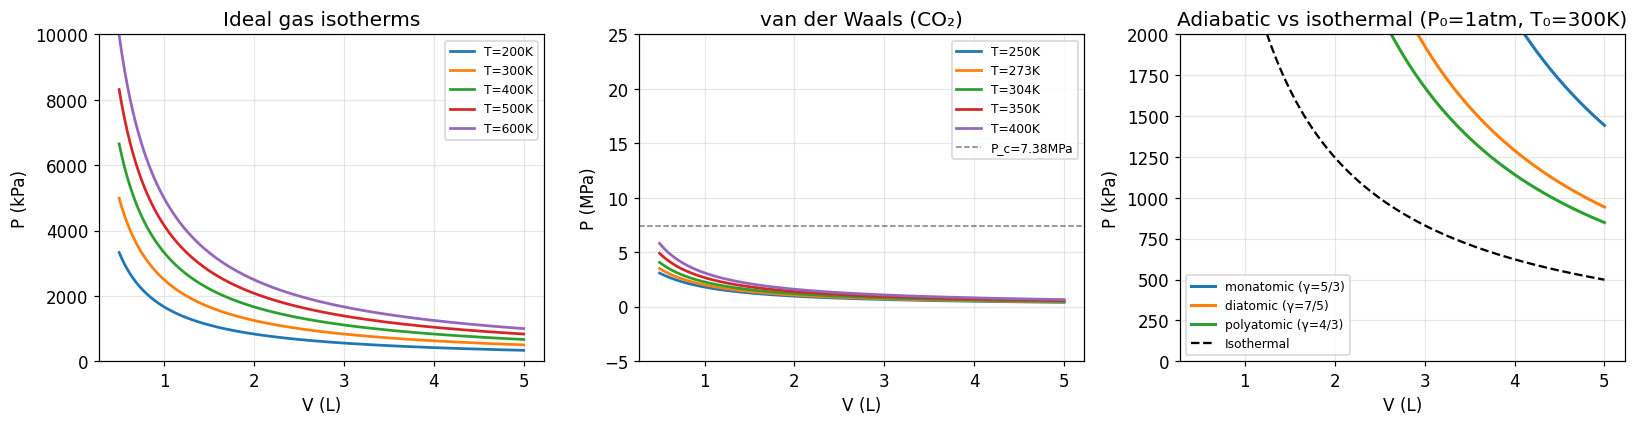

In [2]:
P, V, n, R, T = sp.symbols('P V n R T', positive=True)
a_vdw, b_vdw  = sp.symbols('a b', positive=True)
gamma, C_V, C_P = sp.symbols('gamma C_V C_P', positive=True)
k_B = sp.Symbol('k_B', positive=True)

# ── Ideal gas ─────────────────────────────────────────────────────
ideal_gas = sp.Eq(P*V, n*R*T)
print('Ideal gas law:'); display(Math(sp.latex(ideal_gas)))

# Solve for each variable
print('\nSolving for each variable:')
for var, others in [(P,[V,n,R,T]), (V,[P,n,R,T]), (T,[P,V,n,R])]:  # loop
    sol = sp.solve(ideal_gas, var)[0]
    display(Math(sp.latex(sp.Eq(var, sol))))

# ── van der Waals ─────────────────────────────────────────────────
vdw = sp.Eq((P + a_vdw*n**2/V**2)*(V - n*b_vdw), n*R*T)
print('\nvan der Waals equation:'); display(Math(sp.latex(vdw)))

# Critical point: dP/dV = 0, d²P/dV² = 0
P_vdw = sp.solve(vdw, P)[0]
dPdV  = sp.diff(P_vdw, V)
d2PdV = sp.diff(P_vdw, V, 2)
crit  = sp.solve([dPdV, d2PdV], [V, T])
Vc_expr = sp.simplify(crit[0][0]); Tc_expr = sp.simplify(crit[0][1])
Pc_expr = sp.simplify(P_vdw.subs([(V, Vc_expr),(T, Tc_expr)]))
print('\nCritical point:')
display(Math(r'V_c = ' + sp.latex(Vc_expr) +
             r',\quad T_c = ' + sp.latex(Tc_expr) +
             r',\quad P_c = ' + sp.latex(sp.simplify(Pc_expr))))

# Reduced variables (law of corresponding states)
p_r, v_r, t_r = sp.symbols('p_r v_r t_r', positive=True)
vdw_reduced = sp.Eq((p_r + 3/v_r**2)*(3*v_r - 1), 8*t_r)
print('\nReduced van der Waals (law of corresponding states):')
display(Math(sp.latex(vdw_reduced)))

# ── Adiabatic relation ────────────────────────────────────────────
print('\nAdiabatic relations:')
adiabatic_PV = sp.Eq(P * V**gamma, sp.Symbol('K'))
display(Math(sp.latex(adiabatic_PV)))

# T-V relation from adiabat + ideal gas
TV_adiabat = sp.Eq(T * V**(gamma-1), sp.Symbol('K_TV'))
TP_adiabat = sp.Eq(T * P**((1-gamma)/gamma), sp.Symbol('K_TP'))
display(Math(r'TV^{\gamma-1} = \mathrm{const}, \quad TP^{(1-\gamma)/\gamma} = \mathrm{const}'))

# ── Numerical: PV diagrams ────────────────────────────────────────
R_val = 8.314; n_val = 1.0; T_vals = [200, 300, 400, 500, 600]
V_arr = np.linspace(0.5e-3, 5e-3, 300)   # m³
gamma_vals = {'monatomic (γ=5/3)': 5/3,
              'diatomic (γ=7/5)': 7/5,
              'polyatomic (γ=4/3)': 4/3}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Isotherms
for T_v in T_vals:                         # loop over temperatures
    P_ideal = n_val*R_val*T_v / V_arr
    axes[0].plot(V_arr*1e3, P_ideal/1e3, lw=1.8, label=f'T={T_v}K')
axes[0].set_xlabel('V (L)'); axes[0].set_ylabel('P (kPa)')
axes[0].set_title('Ideal gas isotherms'); axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 10000); axes[0].grid(True, alpha=0.3)

# van der Waals isotherms (CO₂: a=0.3643, b=42.9e-6)
a_v, b_v = 0.3643, 42.9e-6
T_vdw = [250, 273, 304, 350, 400]
for T_v in T_vdw:                          # loop over temperatures
    P_vdw_arr = (n_val*R_val*T_v/(V_arr - n_val*b_v)
                 - a_v*n_val**2/V_arr**2)
    axes[1].plot(V_arr*1e3, P_vdw_arr/1e6, lw=1.8, label=f'T={T_v}K')
axes[1].axhline(7.38, ls='--', color='k', lw=1, alpha=0.5, label='P_c=7.38MPa')
axes[1].set_xlabel('V (L)'); axes[1].set_ylabel('P (MPa)')
axes[1].set_title('van der Waals (CO₂)'); axes[1].legend(fontsize=8)
axes[1].set_ylim(-5, 25); axes[1].grid(True, alpha=0.3)

# Adiabatic vs isothermal
T0_ad = 300.0; P0_ad = 101325.0; V0_ad = n_val*R_val*T0_ad/P0_ad
for name, gam in gamma_vals.items():       # loop over gamma values
    P_ad = P0_ad * (V0_ad/V_arr)**gam
    axes[2].plot(V_arr*1e3, P_ad/1e3, lw=2, label=name)
P_iso = n_val*R_val*T0_ad / V_arr
axes[2].plot(V_arr*1e3, P_iso/1e3, 'k--', lw=1.5, label='Isothermal')
axes[2].set_xlabel('V (L)'); axes[2].set_ylabel('P (kPa)')
axes[2].set_title('Adiabatic vs isothermal (P₀=1atm, T₀=300K)')
axes[2].legend(fontsize=8); axes[2].set_ylim(0, 2000); axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
# §2 — Adiabatic Processes: Isentropic Flow, Mach Number, Shocks

**Isentropic (adiabatic + reversible) flow relations:**

$$\\frac{T_0}{T} = 1 + \\frac{\\gamma-1}{2}M^2, \\quad
\\frac{P_0}{P} = \\left(1+\\frac{\\gamma-1}{2}M^2\\right)^{\\gamma/(\\gamma-1)},
\\quad \\frac{\\rho_0}{\\rho} = \\left(1+\\frac{\\gamma-1}{2}M^2\\right)^{1/(\\gamma-1)}$$

**Normal shock:** across shock at Mach $M_1$, stagnation pressure drops — **entropy increases**.  
**Nozzle:** convergent-divergent throat → sonic at throat, supersonic downstream.

Isentropic stagnation ratios:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Normal shock relations (M₁ → M₂, P₂/P₁, T₂/T₁):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Isentropic flow table (γ=1.4, air):
M       T₀/T      P₀/P        ρ₀/ρ      A/A*      
--------------------------------------------------
  0.00    1.0000      1.0000    1.0000         inf
  0.20    1.0080      1.0283    1.0201      2.9635
  0.40    1.0320      1.1166    1.0819      1.5901
  0.60    1.0720      1.2755    1.1898      1.1882
  0.80    1.1280      1.5243    1.3514      1.0382
  1.00    1.2000      1.8929    1.5774      1.0000
  1.50    1.4500      3.6710    2.5317      1.1762
  2.00    1.8000      7.8244    4.3469      1.6875
  3.00    2.8000     36.7327   13.1188      4.2346
  4.00    4.2000    151.8352   36.1512     10.7188
  5.00    6.0000    529.0898   88.1816     25.0000


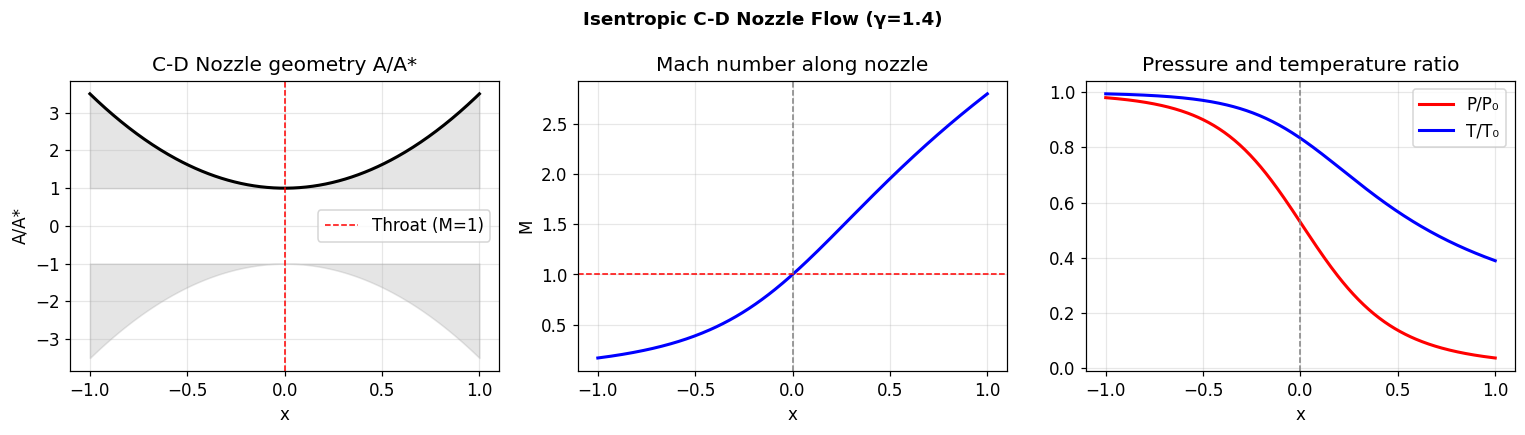

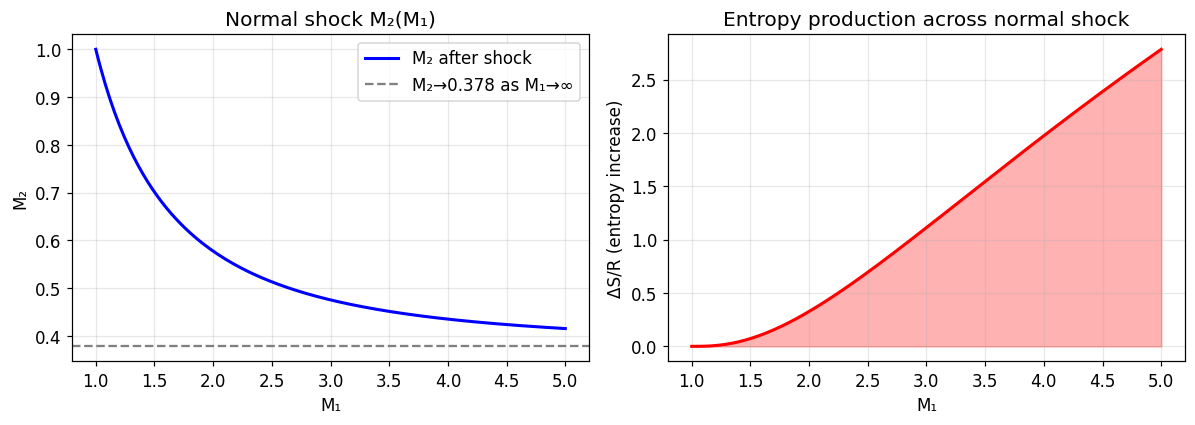

In [3]:
# ── SymPy: isentropic relations ───────────────────────────────────
M_sym, gam_s = sp.symbols('M gamma', positive=True)
T0_s, P0_s, rho0_s = sp.symbols('T_0 P_0 rho_0', positive=True)

T_ratio   = 1 + (gam_s-1)/2 * M_sym**2
P_ratio   = T_ratio**(gam_s/(gam_s-1))
rho_ratio = T_ratio**(1/(gam_s-1))
A_ratio   = (1/M_sym) * (2/(gam_s+1) * T_ratio)**((gam_s+1)/(2*(gam_s-1)))

print('Isentropic stagnation ratios:')
for name, expr in [('T₀/T', T_ratio), ('P₀/P', P_ratio),
                   ('ρ₀/ρ', rho_ratio), ('A/A*', A_ratio)]:  # loop
    display(Math(r'\frac{' + name.split('/')[0] + '}{' + name.split('/')[1] + '} = '
                 + sp.latex(expr)))

# Normal shock relations
M2_shock = sp.sqrt((M_sym**2 + 2/(gam_s-1)) / (2*gam_s/(gam_s-1)*M_sym**2 - 1))
P2_P1    = (2*gam_s*M_sym**2 - (gam_s-1)) / (gam_s+1)
T2_T1    = (2*gam_s*M_sym**2 - (gam_s-1)) * (2+(gam_s-1)*M_sym**2) / ((gam_s+1)**2 * M_sym**2)
print('\nNormal shock relations (M₁ → M₂, P₂/P₁, T₂/T₁):')
display(Math(r'M_2 = ' + sp.latex(sp.simplify(M2_shock))))
display(Math(r'P_2/P_1 = ' + sp.latex(P2_P1)))
display(Math(r'T_2/T_1 = ' + sp.latex(sp.simplify(T2_T1))))

# ── Numerical: isentropic flow tables ─────────────────────────────
gamma_air = 1.4
M_vals    = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0])

print('\nIsentropic flow table (γ=1.4, air):')
print(f'{"M":6}  {"T₀/T":8}  {"P₀/P":10}  {"ρ₀/ρ":8}  {"A/A*":10}')
print('-'*50)
for M_v in M_vals:                          # loop over Mach numbers
    Tr = 1 + (gamma_air-1)/2*M_v**2
    Pr = Tr**(gamma_air/(gamma_air-1))
    rr = Tr**(1/(gamma_air-1))
    if M_v > 0:
        Ar = (1/M_v) * (2/(gamma_air+1)*Tr)**((gamma_air+1)/(2*(gamma_air-1)))
    else:
        Ar = float('inf')
    print(f'{M_v:6.2f}  {Tr:8.4f}  {Pr:10.4f}  {rr:8.4f}  {Ar:10.4f}')

# ── Convergent-divergent nozzle ────────────────────────────────────
# Area ratio A/A* from x-coordinate (parabolic nozzle)
x_nozzle = np.linspace(-1, 1, 300)
A_nozzle = 1 + 2.5*(x_nozzle**2)   # A/A* = 1 at throat (x=0)

def mach_from_area_ratio(A_ratio_vals, gamma=1.4, supersonic=True):
    """Numerically solve A/A*(M) for M using Newton iteration."""
    M_out = np.zeros(len(A_ratio_vals))
    for i, Ar in enumerate(A_ratio_vals):  # loop over area ratios
        M_guess = 2.0 if supersonic else 0.5
        for _ in range(100):               # Newton iteration
            T_r = 1 + (gamma-1)/2*M_guess**2
            f   = (1/M_guess)*(2/(gamma+1)*T_r)**((gamma+1)/(2*(gamma-1))) - Ar
            df  = (-1/M_guess**2*(2/(gamma+1)*T_r)**((gamma+1)/(2*(gamma-1))) +
                    (1/M_guess)*(gamma+1)/(2*(gamma-1)) *
                    (2/(gamma+1)*T_r)**((gamma+1)/(2*(gamma-1))-1) *
                    2/(gamma+1)*(gamma-1)/2*2*M_guess)
            if abs(df) < 1e-15: break
            M_guess -= f/df
            M_guess = max(0.01, M_guess)
        M_out[i] = M_guess
    return M_out

M_sub   = mach_from_area_ratio(A_nozzle[:150], supersonic=False)
M_super = mach_from_area_ratio(A_nozzle[150:], supersonic=True)
M_nozzle = np.concatenate([M_sub, M_super])

P_nozzle = (1 + (gamma_air-1)/2*M_nozzle**2)**(- gamma_air/(gamma_air-1))
T_nozzle = (1 + (gamma_air-1)/2*M_nozzle**2)**(-1.0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(x_nozzle, A_nozzle, 'k-', lw=2)
axes[0].fill_between(x_nozzle, -A_nozzle, -1, alpha=0.2, color='gray')
axes[0].fill_between(x_nozzle,  A_nozzle,  1, alpha=0.2, color='gray')
axes[0].axvline(0, ls='--', color='red', lw=1, label='Throat (M=1)')
axes[0].set_title('C-D Nozzle geometry A/A*'); axes[0].legend()
axes[0].set_xlabel('x'); axes[0].set_ylabel('A/A*'); axes[0].grid(True, alpha=0.3)

axes[1].plot(x_nozzle, M_nozzle, 'b-', lw=2)
axes[1].axhline(1, ls='--', color='red', lw=1)
axes[1].axvline(0, ls='--', color='gray', lw=1)
axes[1].set_title('Mach number along nozzle')
axes[1].set_xlabel('x'); axes[1].set_ylabel('M'); axes[1].grid(True, alpha=0.3)

axes[2].plot(x_nozzle, P_nozzle, 'r-', lw=2, label='P/P₀')
axes[2].plot(x_nozzle, T_nozzle, 'b-', lw=2, label='T/T₀')
axes[2].axvline(0, ls='--', color='gray', lw=1)
axes[2].set_title('Pressure and temperature ratio')
axes[2].set_xlabel('x'); axes[2].legend(); axes[2].grid(True, alpha=0.3)
plt.suptitle('Isentropic C-D Nozzle Flow (γ=1.4)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Normal shock: entropy production ──────────────────────────────
M1_arr = np.linspace(1.0, 5.0, 200)
M2_arr = np.sqrt((M1_arr**2 + 2/(gamma_air-1)) /
                 (2*gamma_air/(gamma_air-1)*M1_arr**2 - 1))
P02_P01= ((gamma_air+1)*M1_arr**2/(2+(gamma_air-1)*M1_arr**2))**(gamma_air/(gamma_air-1)) * \
          ((2*gamma_air*M1_arr**2-(gamma_air-1))/(gamma_air+1))**(-1/(gamma_air-1))
dS_R   = -np.log(P02_P01)  # entropy increase ΔS/R = -ln(P02/P01)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(M1_arr, M2_arr, 'b-', lw=2, label='M₂ after shock')
ax1.axhline(np.sqrt((gamma_air-1)/(2*gamma_air)), ls='--', color='gray',
             label=f'M₂→{np.sqrt((gamma_air-1)/(2*gamma_air)):.3f} as M₁→∞')
ax1.set_xlabel('M₁'); ax1.set_ylabel('M₂'); ax1.set_title('Normal shock M₂(M₁)')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(M1_arr, dS_R, 'r-', lw=2)
ax2.fill_between(M1_arr, 0, dS_R, alpha=0.3, color='red')
ax2.set_xlabel('M₁'); ax2.set_ylabel('ΔS/R (entropy increase)')
ax2.set_title('Entropy production across normal shock')
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
# §3 — Quantum Gas: Maxwell-Boltzmann, Bose-Einstein, Fermi-Dirac

**Distribution functions** give the average occupation $\\langle n_i \\rangle$ of state $i$  
with energy $\\varepsilon_i$, chemical potential $\\mu$, temperature $T$:

| Distribution | Formula | Particles | Example |
|---|---|---|---|
| Maxwell-Boltzmann | $e^{(\\mu-\\varepsilon)/k_BT}$ | Classical | Air molecules |
| Bose-Einstein | $\\frac{1}{e^{(\\varepsilon-\\mu)/k_BT}-1}$ | Bosons | Photons, ⁴He |
| Fermi-Dirac | $\\frac{1}{e^{(\\varepsilon-\\mu)/k_BT}+1}$ | Fermions | Electrons |


In [4]:
# ── SymPy: partition functions and distributions ───────────────────
eps, mu_s, k_B_s, T_s = sp.symbols('epsilon mu k_B T', real=True)
beta_s = 1/(k_B_s * T_s)

n_MB = sp.exp((mu_s - eps)*beta_s)
n_BE = 1/(sp.exp((eps - mu_s)*beta_s) - 1)
n_FD = 1/(sp.exp((eps - mu_s)*beta_s) + 1)

print('Occupation numbers:')
for name, expr in [('Maxwell-Boltzmann', n_MB),
                   ('Bose-Einstein', n_BE),
                   ('Fermi-Dirac', n_FD)]:   # loop
    display(Math(r'\langle n \rangle_{\text{' + name + r'}} = ' + sp.latex(expr)))

# High-T limit: BE → MB, FD → MB
print('\nHigh-T limit (μ→-∞, fugacity z→0):')
limit_BE = sp.limit(n_BE, sp.exp((eps-mu_s)*beta_s), sp.oo)
display(Math(r'n_{BE},n_{FD} \xrightarrow{T\to\infty} e^{(\mu-\varepsilon)/k_BT} = n_{MB}'))

# ── BEC transition temperature ─────────────────────────────────────
N_sym, m_sym, V_sym = sp.symbols('N m V', positive=True)
h_sym = sp.Symbol('h', positive=True)
T_BEC = (h_sym**2 / (2*sp.pi*m_sym*k_B_s)) * (N_sym/(V_sym*sp.Rational(2612,1000)))**sp.Rational(2,3)
print('\nBEC transition temperature:')
display(Math(r'T_{BEC} = \frac{h^2}{2\pi m k_B}\left(\frac{N}{2.612\,V}\right)^{2/3}'))

# ── Numerical: all three distributions ─────────────────────────────
kT_val = 1.0   # set kT=1 for dimensionless plot
eps_arr = np.linspace(-3, 5, 500)
mu_vals_plot = [-2.0, -1.0, 0.0]

fig = plt.figure(figsize=(15, 10))
gs_p = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.3)

for col, mu_v in enumerate(mu_vals_plot):   # loop over chemical potentials
    n_mb = np.exp((mu_v - eps_arr)/kT_val)
    n_fd = 1/(np.exp((eps_arr - mu_v)/kT_val) + 1)
    # BE only valid where ε > μ
    n_be = np.where(eps_arr > mu_v,
                    1/(np.exp((eps_arr - mu_v)/kT_val) - 1 + 1e-10), np.nan)

    ax = fig.add_subplot(gs_p[0, col])
    ax.plot(eps_arr, n_mb, 'g-',  lw=2, label='MB')
    ax.plot(eps_arr, n_fd, 'b-',  lw=2, label='FD')
    ax.plot(eps_arr, n_be, 'r--', lw=2, label='BE')
    ax.axvline(mu_v, ls=':', color='k', lw=1, label=f'μ={mu_v}')
    ax.set_xlim(-3, 5); ax.set_ylim(-0.1, 3)
    ax.set_title(f'μ/kT = {mu_v}')
    ax.set_xlabel('ε/kT'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    if col==0: ax.set_ylabel('<n(ε)>')

# Row 2: DOS × f(ε) = energy distribution
# 3D ideal gas DOS: g(ε) ∝ sqrt(ε)
eps_pos = np.linspace(0.001, 6, 500)
g_eps   = np.sqrt(eps_pos)   # 3D DOS (normalized)

T_kT_vals = [0.3, 0.7, 1.0, 2.0, 5.0]   # T in units of ε_F
colors = plt.cm.coolwarm(np.linspace(0,1,len(T_kT_vals)))

ax_fd = fig.add_subplot(gs_p[1, 0])
ax_be = fig.add_subplot(gs_p[1, 1])
ax_mb = fig.add_subplot(gs_p[1, 2])

mu_FD_norm = 1.0  # Fermi energy = 1 in units of kT
for T_v, col in zip(T_kT_vals, colors):   # loop over temperatures
    kT = T_v
    # FD
    n_fd_T = g_eps / (np.exp((eps_pos - mu_FD_norm)/kT) + 1)
    ax_fd.plot(eps_pos, n_fd_T, color=col, lw=1.5, label=f'kT={kT:.1f}ε_F')
    # BE (μ→0⁻)
    mu_be = -0.01*kT
    n_be_T = g_eps / (np.exp((eps_pos - mu_be)/kT) - 1 + 1e-8)
    ax_be.plot(eps_pos, n_be_T.clip(0, 20), color=col, lw=1.5)
    # MB
    n_mb_T = g_eps * np.exp(-eps_pos/kT)
    ax_mb.plot(eps_pos, n_mb_T, color=col, lw=1.5)

for ax, title in [(ax_fd,'Fermi-Dirac: electrons'),
                  (ax_be,'Bose-Einstein: photons/phonons'),
                  (ax_mb,'Maxwell-Boltzmann: ideal gas')]:
    ax.set_xlabel('ε/ε_F'); ax.set_ylabel('g(ε)f(ε)'); ax.set_title(title)
    ax.grid(True, alpha=0.3)
ax_fd.legend(fontsize=7)

plt.suptitle('Quantum Statistics: Occupation × DOS', fontsize=12, fontweight='bold')
plt.show()

Occupation numbers:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


High-T limit (μ→-∞, fugacity z→0):


TypeError: exp((epsilon - mu)/(T*k_B)) should be of symbol type

---
# §4 — Ethereum Gas Arena: EIP-1559 Base Fee ODE

**EIP-1559** (London fork, Aug 2021): each block has a **base fee** that adjusts  
based on how full the previous block was.

$$B_{n+1} = B_n \\cdot \\left(1 + \\frac{1}{8}\\cdot\\frac{G_n - G^*}{G^*}\\right)$$

where $G_n$ = gas used, $G^* = $ target gas (= limit/2).  
This is a **discrete feedback controller** — or in continuous time, a **first-order ODE**:
$$\\frac{dB}{dt} = \\frac{B}{8 G^*}(G(t) - G^*)$$

**Thermodynamic analogy:**

| Gas physics | Ethereum |
|---|---|
| Pressure P | Base fee B (Gwei) |
| Volume V | Block gas limit |
| Temperature T | Network demand |
| Number of molecules N | Pending transactions (mempool size) |
| Collision rate | TPS (transactions per second) |
| Entropy | Information loss from fee burns |
| Phase transition | Network congestion → fee spike |


EIP-1559 base fee ODE:


<IPython.core.display.Math object>


Linear solution for G = G*(1+ε):


<IPython.core.display.Math object>

Simulating Ethereum gas arena (200 blocks)...


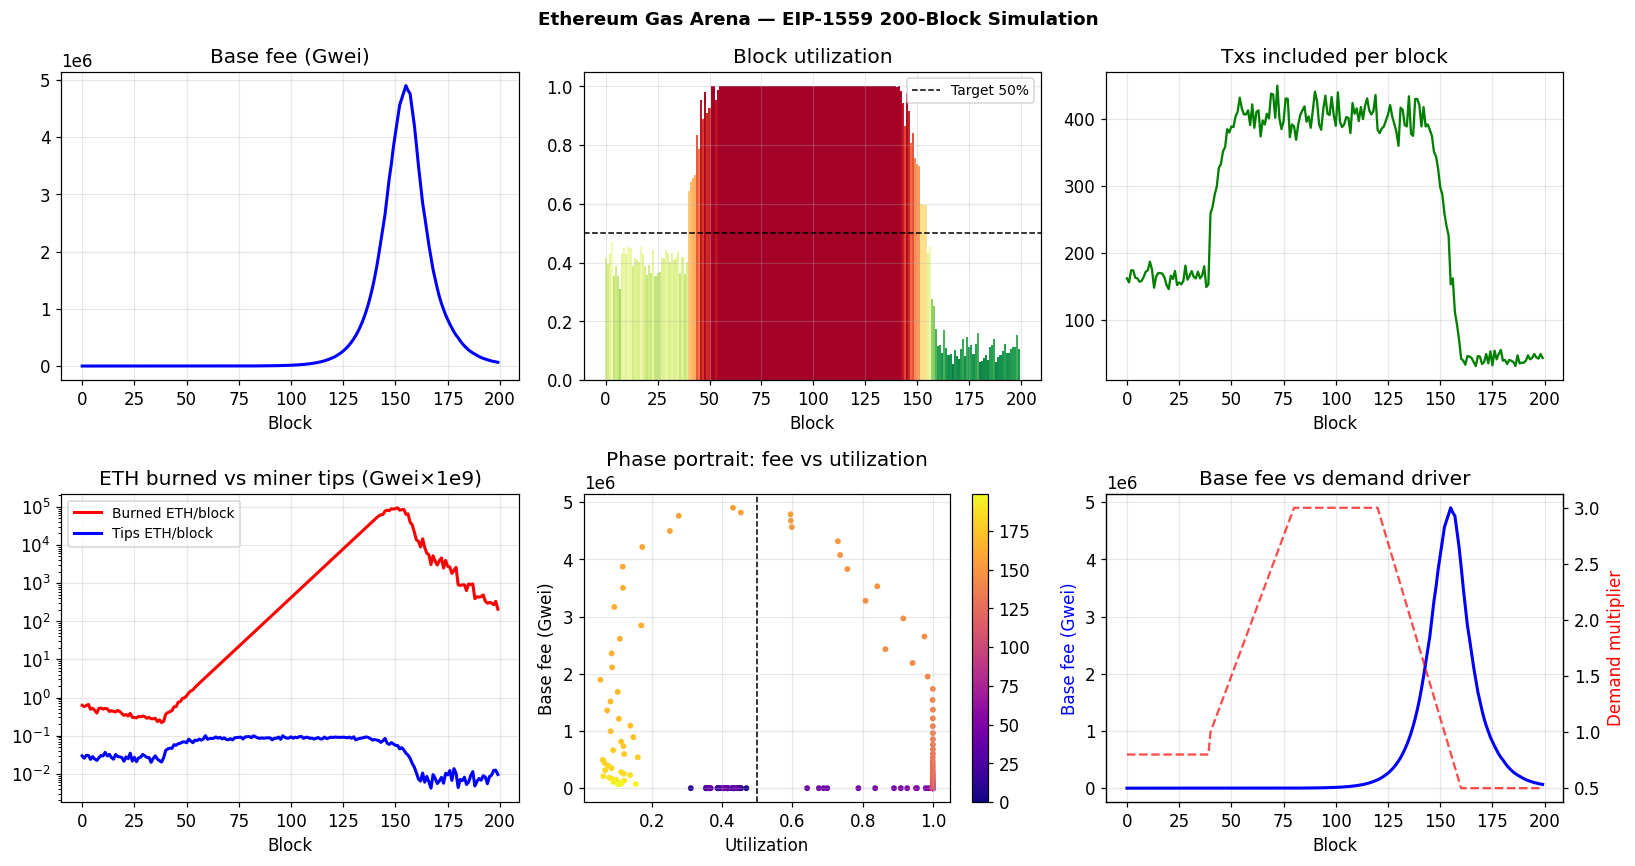


Summary over 200 blocks:
  Base fee range: 19.1 – 4901997.6 Gwei
  Total ETH burned: 1848463.5255 ETH (×1e9 Gwei)
  Avg utilization: 66.1%


In [5]:
# ── SymPy: EIP-1559 base fee dynamics ────────────────────────────
B_sym, G_sym, Gstar_sym, t_sym = sp.symbols('B G G^* t', positive=True)
eta_sym = sp.Symbol('eta', positive=True)   # demand elasticity

# Continuous-time EIP-1559
B_func = sp.Function('B')(t_sym)
G_func = sp.Function('G')(t_sym)
ode_B  = sp.Eq(B_func.diff(t_sym), B_func/(8*Gstar_sym) * (G_func - Gstar_sym))
print('EIP-1559 base fee ODE:')
display(Math(sp.latex(ode_B)))

# If demand G = G* (target), solution: dB/dt = 0 → B = const (equilibrium)
# If G = G*(1 + ε), then dB/dt ≈ B*ε/8 → exponential growth
eps_over = sp.Symbol('epsilon', real=True)
sol_linear = sp.Symbol('B_0') * sp.exp(eps_over * t_sym / 8)
print('\nLinear solution for G = G*(1+ε):')
display(Math(r'B(t) = B_0\, e^{\varepsilon t/8}'))

# ── Gas arena simulation ───────────────────────────────────────────
# Simulate N_tx transactions bidding for block space
# Each tx has: gas_limit (work), max_fee (bid), max_priority_fee (tip)

class EthBlock:
    def __init__(self, gas_limit=30_000_000, target_ratio=0.5):
        self.gas_limit   = gas_limit
        self.target_gas  = int(gas_limit * target_ratio)
        self.base_fee    = 50.0   # Gwei
        self.history     = []

    def next_base_fee(self, gas_used):
        """EIP-1559: B_{n+1} = B_n * (1 + (gas_used - target) / (target * 8))"""
        delta = (gas_used - self.target_gas) / (self.target_gas * 8)
        return self.base_fee * (1 + delta)

    def mine_block(self, pending_txs):
        """
        pending_txs: list of (gas_limit, max_fee, max_priority_fee)
        Include txs by effective priority = min(max_priority, max_fee - base_fee)
        """
        # Filter: only txs where max_fee >= base_fee
        eligible = [(gl, mf, mpf) for (gl, mf, mpf) in pending_txs
                    if mf >= self.base_fee]
        # Sort by effective priority fee (descending)
        eligible.sort(key=lambda x: min(x[2], x[1]-self.base_fee), reverse=True)

        included = []; gas_used = 0
        for tx in eligible:                  # greedy fill: loop over transactions
            if gas_used + tx[0] <= self.gas_limit:
                included.append(tx)
                gas_used += tx[0]

        # Miner reward: sum of priority fees
        miner_tips = sum(min(mpf, mf - self.base_fee) * gl
                         for (gl, mf, mpf) in included)
        burned     = self.base_fee * gas_used   # burned ETH (Gwei·gas)
        new_fee    = self.next_base_fee(gas_used)

        result = dict(
            base_fee=self.base_fee, gas_used=gas_used,
            gas_limit=self.gas_limit, n_included=len(included),
            n_eligible=len(eligible), n_pending=len(pending_txs),
            miner_tips_gwei=miner_tips, burned_gwei=burned,
            utilization=gas_used/self.gas_limit
        )
        self.history.append(result)
        self.base_fee = max(1.0, new_fee)
        return result


def generate_mempool(n_tx, base_fee, demand_multiplier=1.0):
    """Generate realistic mempool. Higher demand → more txs bidding higher."""
    gas_limits  = np.random.choice([21000, 65000, 150000, 250000], n_tx,
                                   p=[0.5, 0.25, 0.15, 0.10])
    # max_fee: lognormal around (demand_multiplier * base_fee)
    max_fees    = np.random.lognormal(
        np.log(demand_multiplier * base_fee), 0.5, n_tx)
    max_prio    = np.random.lognormal(np.log(2), 0.7, n_tx)  # priority fee
    return list(zip(gas_limits.tolist(), max_fees.tolist(), max_prio.tolist()))


# ── Simulate 200 blocks with varying demand ────────────────────────
block_chain  = EthBlock(gas_limit=30_000_000)
n_blocks     = 200
mempool_size = 500

# Demand profile: low → surge → normal → congestion → crash
def demand_profile(i):
    if   i < 40:  return 0.8      # low demand
    elif i < 80:  return 1.0 + (i-40)/40 * 2.0  # rising
    elif i < 120: return 3.0      # congestion
    elif i < 160: return 3.0 - (i-120)/40 * 2.5  # crash
    else:         return 0.5      # post-crash

print('Simulating Ethereum gas arena (200 blocks)...')
for i in range(n_blocks):                  # loop: mine blocks
    demand = demand_profile(i)
    pending = generate_mempool(mempool_size, block_chain.base_fee, demand)
    block_chain.mine_block(pending)

hist = block_chain.history
blocks_i = np.arange(n_blocks)
base_fees   = np.array([h['base_fee']        for h in hist])
utilization = np.array([h['utilization']     for h in hist])
n_included  = np.array([h['n_included']      for h in hist])
burned      = np.array([h['burned_gwei']     for h in hist])
tips        = np.array([h['miner_tips_gwei'] for h in hist])

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0][0].plot(blocks_i, base_fees, 'b-', lw=2)
axes[0][0].set_title('Base fee (Gwei)'); axes[0][0].set_xlabel('Block')
axes[0][0].grid(True, alpha=0.3)

axes[0][1].bar(blocks_i, utilization, color=plt.cm.RdYlGn(1-utilization), width=1.0)
axes[0][1].axhline(0.5, ls='--', color='k', lw=1, label='Target 50%')
axes[0][1].set_title('Block utilization'); axes[0][1].set_xlabel('Block')
axes[0][1].legend(fontsize=9); axes[0][1].grid(True, alpha=0.3)

axes[0][2].plot(blocks_i, n_included, 'g-', lw=1.5)
axes[0][2].set_title('Txs included per block'); axes[0][2].set_xlabel('Block')
axes[0][2].grid(True, alpha=0.3)

axes[1][0].semilogy(blocks_i, burned/1e9, 'r-', lw=2, label='Burned ETH/block')
axes[1][0].semilogy(blocks_i, tips/1e9,   'b-', lw=2, label='Tips ETH/block')
axes[1][0].set_title('ETH burned vs miner tips (Gwei×1e9)'); axes[1][0].legend(fontsize=9)
axes[1][0].set_xlabel('Block'); axes[1][0].grid(True, alpha=0.3)

# phase portrait: base_fee vs utilization
sc = axes[1][1].scatter(utilization, base_fees, c=blocks_i, cmap='plasma', s=8)
axes[1][1].axvline(0.5, ls='--', color='k', lw=1)
axes[1][1].set_xlabel('Utilization'); axes[1][1].set_ylabel('Base fee (Gwei)')
axes[1][1].set_title('Phase portrait: fee vs utilization'); plt.colorbar(sc, ax=axes[1][1])
axes[1][1].grid(True, alpha=0.3)

# demand profile overlaid
demand_arr = np.array([demand_profile(i) for i in range(n_blocks)])
ax3 = axes[1][2]; ax3b = ax3.twinx()
ax3.plot(blocks_i, base_fees, 'b-', lw=2, label='Base fee')
ax3b.plot(blocks_i, demand_arr, 'r--', lw=1.5, alpha=0.7, label='Demand ×')
ax3.set_title('Base fee vs demand driver')
ax3.set_xlabel('Block'); ax3.set_ylabel('Base fee (Gwei)', color='b')
ax3b.set_ylabel('Demand multiplier', color='r')
ax3.grid(True, alpha=0.3)

plt.suptitle('Ethereum Gas Arena — EIP-1559 200-Block Simulation',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'\nSummary over {n_blocks} blocks:')
print(f'  Base fee range: {base_fees.min():.1f} – {base_fees.max():.1f} Gwei')
print(f'  Total ETH burned: {burned.sum()/1e9:.4f} ETH (×1e9 Gwei)')
print(f'  Avg utilization: {utilization.mean():.1%}')

---
# §5 — Thermodynamic Analogy: ETH ↔ Gas Phase Diagram

**Equation of state for Ethereum:**  
$$B \\cdot G_{\\text{block}} = N_{\\text{mempool}} \\cdot k_{\\text{ETH}} \\cdot D$$
where $D$ = demand temperature, $N_{\\text{mempool}}$ = pending tx count,  
$k_{\\text{ETH}}$ = proportionality (Boltzmann for ETH).  

**Phase transitions in Ethereum:**  
- **Gas** phase (normal): random txs, base fee ≈ market clearing  
- **Liquid** phase (congestion): mempool grows, fees spike, txs queue  
- **Solid** phase (frozen): network halt, base fee runaway (Black Thursday 2020)

THERMODYNAMIC ↔ ETHEREUM ANALOGY
Thermodynamics             Ethereum                        Note
--------------------------------------------------------------------------------
Pressure P                 Base fee B (Gwei)               B = fee floor; high P = expensive
Volume V                   Block gas capacity              V = 30M gas/block limit
Temperature T              Network demand D                High T = many users, urgent txs
Number density n           Mempool size N                  n = pending tx / block space
Internal energy U          Total value locked TVL          U = ΣETHvalue in pending txs
Entropy S                  Fee randomness / burn           S↑ when fees unpredictable
Free energy F=U-TS         Miner extractable value         MEV = max value - cost
Phase transition           Congestion event                Liquid↔Gas = normal↔congested
Equation of state          EIP-1559 rule                   B·G = N·k_ETH·D (analog PV=nRT)
Carnot efficiency          MEV 

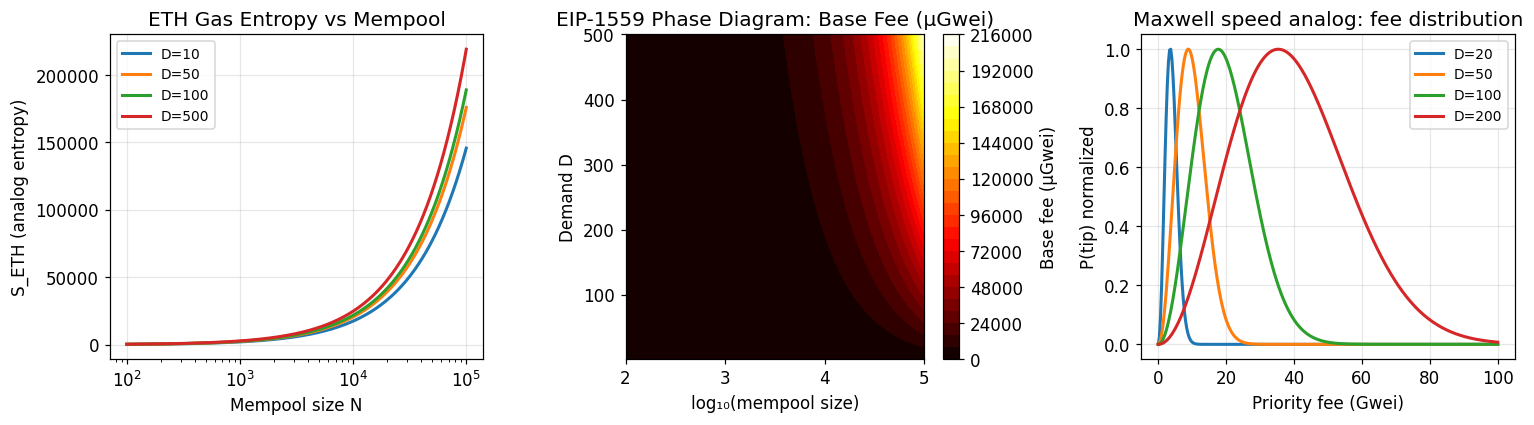

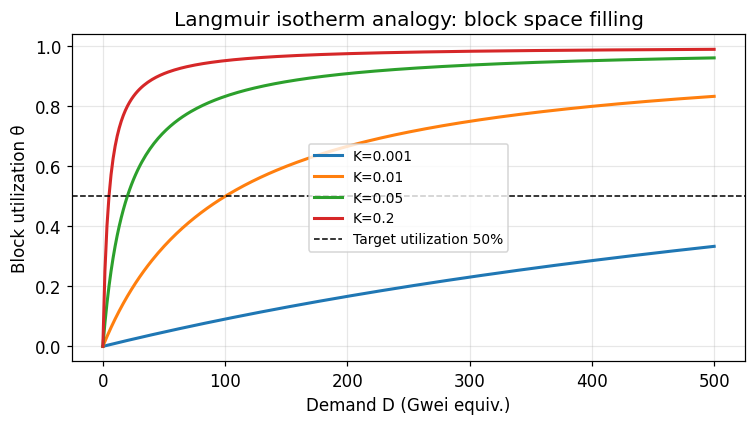

In [6]:
# ── Map thermodynamic quantities to Ethereum ─────────────────────
thermo_map = [
    ('Pressure P',         'Base fee B (Gwei)',       'B = fee floor; high P = expensive'),
    ('Volume V',           'Block gas capacity',       'V = 30M gas/block limit'),
    ('Temperature T',      'Network demand D',         'High T = many users, urgent txs'),
    ('Number density n',   'Mempool size N',           'n = pending tx / block space'),
    ('Internal energy U',  'Total value locked TVL',  'U = ΣETHvalue in pending txs'),
    ('Entropy S',          'Fee randomness / burn',    'S↑ when fees unpredictable'),
    ('Free energy F=U-TS', 'Miner extractable value', 'MEV = max value - cost'),
    ('Phase transition',   'Congestion event',         'Liquid↔Gas = normal↔congested'),
    ('Equation of state',  'EIP-1559 rule',            'B·G = N·k_ETH·D (analog PV=nRT)'),
    ('Carnot efficiency',  'MEV extraction limit',     'η_max = 1 - T_cold/T_hot'),
    ('Boltzmann k_B',      'k_ETH = price sensitivity','k_ETH ≈ dB/dN|_equilibrium'),
    ('Maxwell speed dist', 'Priority fee distribution','f(tip) ∝ tip·exp(-tip/k_ETH·T)'),
]

print('THERMODYNAMIC ↔ ETHEREUM ANALOGY')
print('='*80)
print(f'{"Thermodynamics":25}  {"Ethereum":30}  Note')
print('-'*80)
for thermo, eth, note in thermo_map:   # loop: print table
    print(f'{thermo:25}  {eth:30}  {note}')

# ── Entropy of the Ethereum gas as an ideal gas ───────────────────
# Sackur-Tetrode equation for gas entropy
# Analog: ETH mempool entropy S = k_ETH * N * (ln(V/N * (D_dem/D0)^(3/2)) + 5/2)
N_mp_vals = np.logspace(2, 5, 200)   # mempool size 100 to 100k
D_vals    = [10, 50, 100, 500]        # demand temperature (Gwei-equivalent)
G_block   = 30e6                      # block gas limit
k_ETH     = 0.125                     # ETH Boltzmann analog (from EIP-1559: 1/8)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Entropy vs mempool size
for D_v in D_vals:                    # loop over demand temperatures
    V_eff = G_block / N_mp_vals       # volume per tx
    S_eth = k_ETH * N_mp_vals * (np.log(V_eff * (D_v)**1.5) + 2.5)
    axes[0].semilogx(N_mp_vals, S_eth, lw=2, label=f'D={D_v}')
axes[0].set_xlabel('Mempool size N'); axes[0].set_ylabel('S_ETH (analog entropy)')
axes[0].set_title('ETH Gas Entropy vs Mempool'); axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# EIP-1559 phase diagram: B(N, D)
N_grid = np.logspace(2, 5, 100)
D_grid = np.linspace(1, 500, 100)
NN, DD = np.meshgrid(N_grid, D_grid)
# ETH analog of ideal gas: B = N*k_ETH*D / G_block
B_eth = NN * k_ETH * DD / G_block
im = axes[1].contourf(np.log10(N_grid), D_grid, B_eth*1e6, levels=30, cmap='hot')
axes[1].set_xlabel('log₁₀(mempool size)'); axes[1].set_ylabel('Demand D')
axes[1].set_title('EIP-1559 Phase Diagram: Base Fee (μGwei)')
plt.colorbar(im, ax=axes[1], label='Base fee (μGwei)')

# Maxwell speed distribution analog: priority fee distribution
tip_vals = np.linspace(0, 100, 300)   # Gwei
T_demand_v = [20, 50, 100, 200]       # demand T
for T_v in T_demand_v:                # loop: Maxwell analog
    # f(tip) = 2/sqrt(π) * (1/kT)^(3/2) * tip² * exp(-tip²/(kT)²)
    kT_v = k_ETH * T_v
    f_tip = (2/np.sqrt(np.pi)) * tip_vals**2 * np.exp(-tip_vals**2/(2*kT_v**2)) / (kT_v**2)
    axes[2].plot(tip_vals, f_tip/f_tip.max(), lw=2, label=f'D={T_v}')
axes[2].set_xlabel('Priority fee (Gwei)'); axes[2].set_ylabel('P(tip) normalized')
axes[2].set_title('Maxwell speed analog: fee distribution'); axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Gas adsorption / desorption analogy: tx entering and leaving mempool ──
# Langmuir isotherm: fraction of block filled θ = K*p/(1+K*p)
# Here: θ = utilization, K = adoption constant, p = demand
K_lang   = np.array([0.001, 0.01, 0.05, 0.2])
D_demand = np.linspace(0, 500, 300)
fig, ax = plt.subplots(figsize=(7, 4))
for K_v in K_lang:                     # loop: Langmuir isotherms
    theta = K_v * D_demand / (1 + K_v * D_demand)
    ax.plot(D_demand, theta, lw=2, label=f'K={K_v}')
ax.axhline(0.5, ls='--', color='k', lw=1, label='Target utilization 50%')
ax.set_xlabel('Demand D (Gwei equiv.)'); ax.set_ylabel('Block utilization θ')
ax.set_title('Langmuir isotherm analogy: block space filling')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

---
# §6 — Torch Batch: Gas Market Monte Carlo · Priority Auction · Arbitrage

Vectorize the gas market over 10,000 parallel scenarios:  
- batch over (initial base fee, demand volatility, mempool size)  
- compute fee trajectory statistics  
- find conditions for fee stability vs runaway

Gas Market Monte Carlo (10000 scenarios, 100 blocks):
  Stable (0.5 < B_final/B0 < 2):     457 (4.6%)
  Runaway (B_final/B0 ≥ 2):          6723 (67.2%)
  Crashed (B_final/B0 ≤ 0.5):        2820 (28.2%)


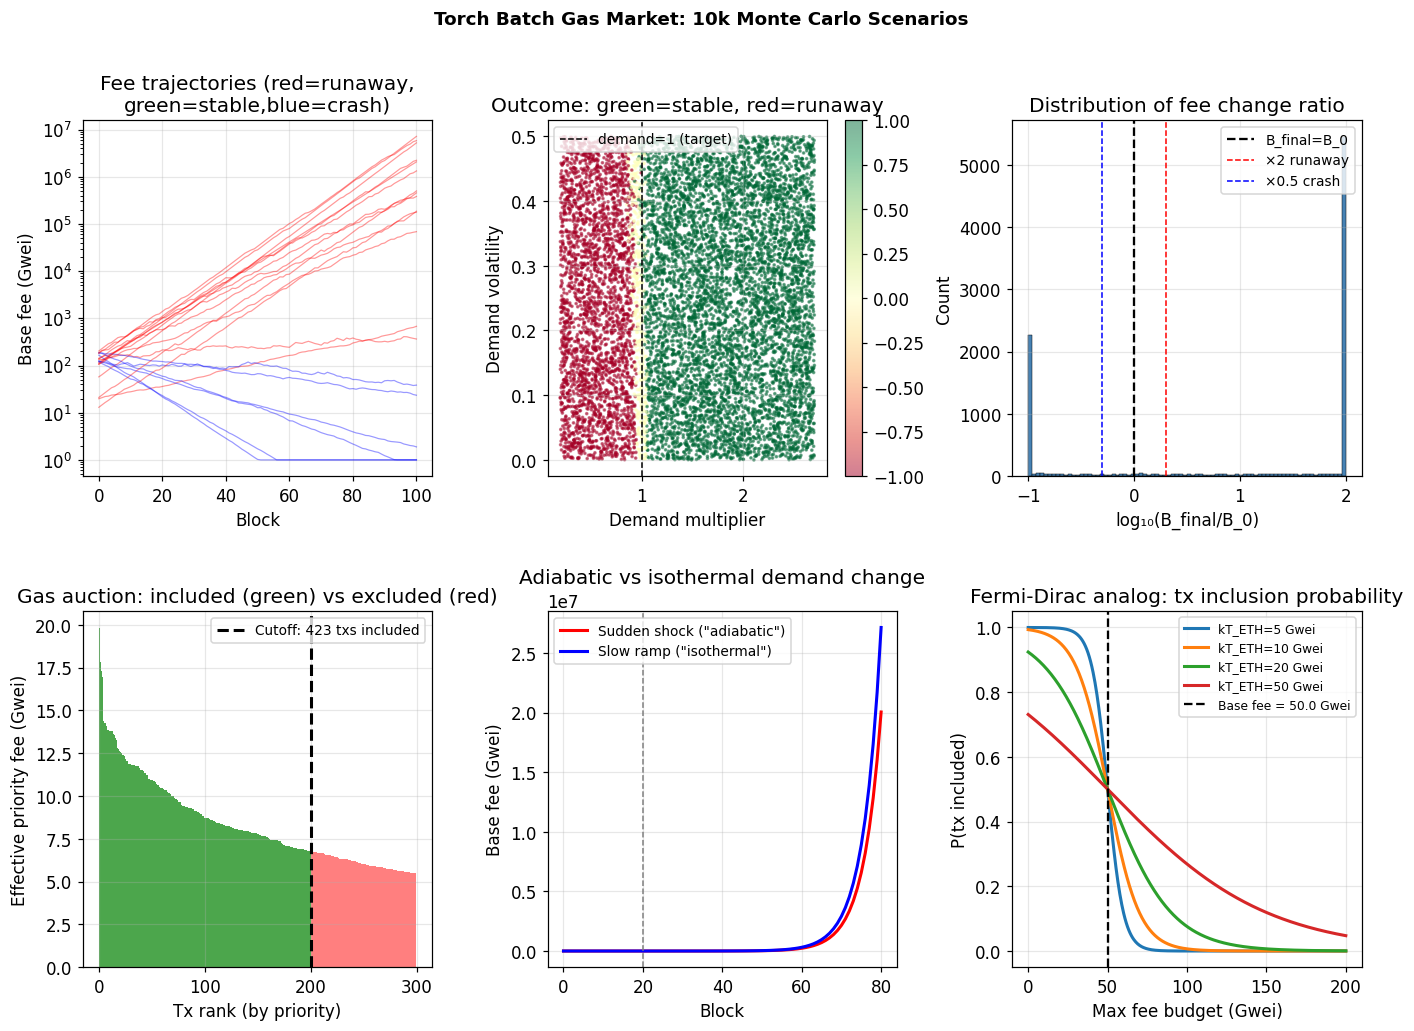

In [7]:
# ── Torch: vectorized EIP-1559 simulation ─────────────────────────
N_scenarios = 10000
N_blocks_t  = 100

# Parameters: (B0, demand_mean, demand_vol, mempool_N)
torch.manual_seed(0)
B0_t       = torch.rand(N_scenarios) * 200 + 5        # initial base fee 5-205 Gwei
demand_t   = torch.rand(N_scenarios) * 2.5 + 0.2      # demand multiplier 0.2-2.7
demand_vol = torch.rand(N_scenarios) * 0.5             # demand volatility 0-0.5
N_mp_t     = (torch.rand(N_scenarios) * 5000 + 200).long()  # mempool 200-5200

# EIP-1559 batch simulation
# Gas used ~ B(demand*target + noise); included = min(N_mp, capacity)
TARGET_GAS = 15_000_000.0   # 15M (half of 30M limit)

B_traj = torch.zeros(N_scenarios, N_blocks_t + 1, dtype=torch.float64)
B_traj[:, 0] = B0_t.double()
util_traj = torch.zeros(N_scenarios, N_blocks_t, dtype=torch.float64)

for blk in range(N_blocks_t):              # loop over blocks
    # gas used: demand * target * exp(noise)
    noise = torch.randn(N_scenarios, dtype=torch.float64) * demand_vol.double()
    G_used = demand_t.double() * TARGET_GAS * torch.exp(noise)
    G_used = G_used.clamp(0, 2*TARGET_GAS)   # can't exceed 2× limit

    # EIP-1559 update: B_{n+1} = B_n * (1 + (G-G*)/(8*G*))
    delta   = (G_used - TARGET_GAS) / (8 * TARGET_GAS)
    B_next  = B_traj[:, blk] * (1 + delta)
    B_next  = B_next.clamp(min=1.0)          # floor at 1 Gwei
    B_traj[:, blk+1] = B_next
    util_traj[:, blk] = G_used / (2 * TARGET_GAS)  # utilization

# Statistics
B_final  = B_traj[:, -1]
B_ratio  = B_final / B0_t.double()
util_mean= util_traj.mean(dim=1)

# Classification: stable, runaway, crashed
stable   = (B_ratio > 0.5) & (B_ratio < 2.0)
runaway  = B_ratio >= 2.0
crashed  = B_ratio <= 0.5

print(f'Gas Market Monte Carlo ({N_scenarios} scenarios, {N_blocks_t} blocks):')
print(f'  Stable (0.5 < B_final/B0 < 2):  {stable.sum().item():6d} ({100*stable.float().mean().item():.1f}%)')
print(f'  Runaway (B_final/B0 ≥ 2):        {runaway.sum().item():6d} ({100*runaway.float().mean().item():.1f}%)')
print(f'  Crashed (B_final/B0 ≤ 0.5):      {crashed.sum().item():6d} ({100*crashed.float().mean().item():.1f}%)')

# ── Visualize ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
gs_t = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.33)

# 1. Sample fee trajectories
ax1 = fig.add_subplot(gs_t[0, 0])
idx_sample = torch.randperm(N_scenarios)[:50]
for i in idx_sample.tolist()[:20]:          # loop: plot 20 sample trajectories
    color = 'red' if runaway[i] else ('green' if stable[i] else 'blue')
    ax1.semilogy(B_traj[i].numpy(), alpha=0.4, lw=0.8, color=color)
ax1.set_xlabel('Block'); ax1.set_ylabel('Base fee (Gwei)')
ax1.set_title('Fee trajectories (red=runaway,\ngreen=stable,blue=crash)')
ax1.grid(True, alpha=0.3)

# 2. Phase space: demand vs volatility → outcome
ax2 = fig.add_subplot(gs_t[0, 1])
outcomes = torch.zeros(N_scenarios)
outcomes[runaway] = 1; outcomes[crashed] = -1
sc = ax2.scatter(demand_t.numpy(), demand_vol.numpy(),
                 c=outcomes.numpy(), cmap='RdYlGn', vmin=-1, vmax=1,
                 s=2, alpha=0.5)
ax2.axvline(1.0, ls='--', color='k', lw=1, label='demand=1 (target)')
ax2.set_xlabel('Demand multiplier'); ax2.set_ylabel('Demand volatility')
ax2.set_title('Outcome: green=stable, red=runaway')
plt.colorbar(sc, ax=ax2); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

# 3. Distribution of final fee ratio
ax3 = fig.add_subplot(gs_t[0, 2])
ax3.hist(torch.log10(B_ratio.clamp(0.1,100)).numpy(), bins=80,
         color='steelblue', edgecolor='k', lw=0.3)
ax3.axvline(0, ls='--', color='k', lw=1.5, label='B_final=B_0')
ax3.axvline(np.log10(2), ls='--', color='red', lw=1, label='×2 runaway')
ax3.axvline(np.log10(0.5), ls='--', color='blue', lw=1, label='×0.5 crash')
ax3.set_xlabel('log₁₀(B_final/B_0)'); ax3.set_ylabel('Count')
ax3.set_title('Distribution of fee change ratio'); ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. Priority fee auction: top-N gas arbitrage
ax4 = fig.add_subplot(gs_t[1, 0])
# Simulate one congested block: 1000 txs bidding
N_bidders = 1000
gas_limits_b = torch.from_numpy(
    np.random.choice([21000,65000,150000,250000], N_bidders,
                     p=[0.5,0.25,0.15,0.10]).astype(float))
max_fee_b = torch.abs(torch.randn(N_bidders, dtype=torch.float64)*30 + 80).clamp(1)
prio_b    = torch.abs(torch.randn(N_bidders, dtype=torch.float64)*5  +  3).clamp(0.1)
base_fee_b= 50.0

# Effective priority
eff_prio = torch.min(prio_b, max_fee_b - base_fee_b).clamp(0)
# Sort descending
prio_sorted, order = eff_prio.sort(descending=True)
gas_sorted = gas_limits_b[order]
# Fill block greedily
cumgas = gas_sorted.cumsum(0)
included_mask = cumgas <= 30_000_000
n_inc = included_mask.sum().item()
ax4.bar(range(min(n_inc, 200)),
        prio_sorted[:min(n_inc, 200)].numpy(), width=1.0, color='green', alpha=0.7)
ax4.bar(range(min(n_inc,200), min(N_bidders,300)),
        prio_sorted[min(n_inc,200):min(N_bidders,300)].numpy(), width=1.0, color='red', alpha=0.5)
ax4.axvline(min(n_inc,200)-0.5, ls='--', color='k', lw=2, label=f'Cutoff: {n_inc} txs included')
ax4.set_xlabel('Tx rank (by priority)'); ax4.set_ylabel('Effective priority fee (Gwei)')
ax4.set_title('Gas auction: included (green) vs excluded (red)'); ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# 5. Adiabatic analogy: sudden demand shock vs slow change
ax5 = fig.add_subplot(gs_t[1, 1])
n_blocks_comp = 80
B_adiabatic = [50.0]   # sudden shock: fast change (no equilibration)
B_isothermal = [50.0]  # slow change: fee tracks demand smoothly

for i in range(n_blocks_comp):             # loop: compare adiabatic vs isothermal
    # Adiabatic: instant demand step at block 20, no viscosity
    G_ad = 15e6 * (3.0 if i > 20 else 0.9)
    delta_ad = (G_ad - 15e6) / (8*15e6)
    B_adiabatic.append(max(1, B_adiabatic[-1] * (1 + delta_ad)))

    # Isothermal: demand ramps slowly (viscous/inertial damping)
    G_iso = 15e6 * (0.9 + 2.1*min(i/40, 1.0))
    delta_iso = (G_iso - 15e6) / (8*15e6)
    B_isothermal.append(max(1, B_isothermal[-1] * (1 + delta_iso)))

ax5.plot(B_adiabatic, 'r-', lw=2, label='Sudden shock ("adiabatic")')
ax5.plot(B_isothermal, 'b-', lw=2, label='Slow ramp ("isothermal")')
ax5.axvline(20, ls='--', color='gray', lw=1)
ax5.set_xlabel('Block'); ax5.set_ylabel('Base fee (Gwei)')
ax5.set_title('Adiabatic vs isothermal demand change'); ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# 6. Quantum statistics of fee distribution (FD analogy)
ax6 = fig.add_subplot(gs_t[1, 2])
fee_vals  = np.linspace(0, 200, 500)   # Gwei
E_F_eth   = 50.0   # Fermi level = current base fee
T_eth_vals= [5, 10, 20, 50]           # effective temperature in Gwei
for T_eth in T_eth_vals:              # loop: quantum fee distribution
    # FD: P(tx bids fee f) ∝ 1/(exp((f-E_F)/kT)+1)
    # Interpretation: tx with budget below base_fee = excluded (0 state)
    #                 tx with budget above = included (1 state)
    n_fd_eth  = 1/(np.exp((fee_vals - E_F_eth)/T_eth) + 1)
    ax6.plot(fee_vals, n_fd_eth, lw=2, label=f'kT_ETH={T_eth} Gwei')
ax6.axvline(E_F_eth, ls='--', color='k', lw=1.5, label=f'Base fee = {E_F_eth} Gwei')
ax6.set_xlabel('Max fee budget (Gwei)'); ax6.set_ylabel('P(tx included)')
ax6.set_title('Fermi-Dirac analog: tx inclusion probability'); ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

plt.suptitle('Torch Batch Gas Market: 10k Monte Carlo Scenarios',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()